In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

C:\Users\ronin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We will illustrate some further Stan concepts and practices based on our simple Bayesian regression:
$$
\begin{align}
    \nonumber \sigma^2 &\sim \text{Inv-Gamma}(1, 1)\\
    \nonumber \alpha &\sim \mathcal{N}(0, 10)\\
    \nonumber \beta &\sim \mathcal{N}(0, 10)\\
\nonumber y_n &\sim \mathcal{N}(\alpha + \beta\,x_n, \sigma^2) \quad \text{for} \,\, n = 1,\dots,N
\end{align}
$$

## Data Creation

In [6]:
# simulating the data...
N = 100
alpha = 2.3
sigma = 2.
slope = 4.
x = np.random.normal(size=N)
y = alpha + slope * x + sigma * np.random.normal(size=N)

# creating Stan-friendly data dictionary...
data_dict = {
    "N": N,
    "x": x,
    "y": y
}



## Vectorized Model

In [5]:
model = CmdStanModel(stan_file="models/q5.stan")

21:06:07 - cmdstanpy - INFO - compiling stan file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw3\models\q5.stan to exe file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw3\models\q5.exe
21:06:25 - cmdstanpy - INFO - compiled model executable: C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw3\models\q5.exe


In [7]:
fit = model.sample(
    data=data_dict, 
    chains=4, 
    iter_warmup=500, 
    iter_sampling=5000,
)

21:09:00 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]




chain 1:  22%|██▏       | 1200/5500 [00:00<00:00, 11619.32it/s, (Sampling)]


chain 1:  65%|██████▌   | 3600/5500 [00:00<00:00, 18782.27it/s, (Sampling)]


chain 2: 100%|██████████| 5500/5500 [00:00<00:00, 18748.78it/s, (Sampling completed)]

chain 3: 100%|██████████| 5500/5500 [00:00<00:00, 18684.88it/s, (Sampling completed)]


chain 4: 100%|██████████| 5500/5500 [00:00<00:00, 18782.76it/s, (Sampling completed)]


21:09:01 - cmdstanpy - INFO - CmdStan done processing.
21:09:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'q5.stan', line 25, column 4 to column 55)
Consider re-running with show_console=True if the above output is unclear!


In [8]:
fit.summary()


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-221.06500,0.013220,1.253700,1.001540,-223.57000,-220.73300,-219.71900,9763.57,12828.6,11834.6,1.000300
alpha,2.16020,0.001561,0.203252,0.201203,1.82802,2.15998,2.49396,17044.20,13885.5,20659.6,1.000080
beta,4.41439,0.001476,0.205950,0.206518,4.07751,4.41422,4.75101,19505.60,13335.6,23643.1,0.999961
sigma2,4.11532,0.004353,0.599369,0.578202,3.24835,4.04928,5.17904,19819.40,14820.9,24023.5,1.000360
sigma,2.02338,0.001049,0.145775,0.143882,1.80232,2.01228,2.27575,19819.40,14820.9,24023.5,1.000380


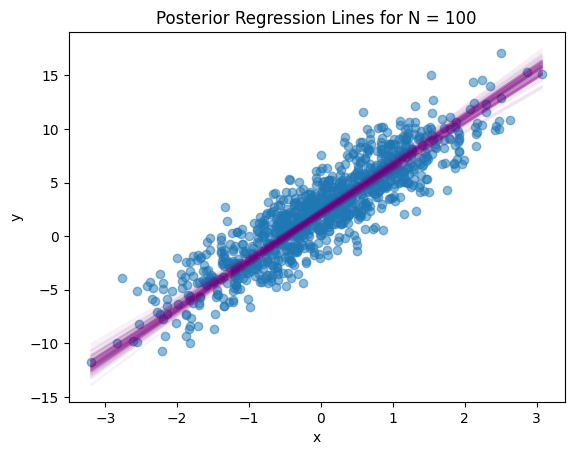

In [16]:
# graphically summarising results via scatter plot...
plt.scatter(x, y, alpha=0.5, label="Data")

# posterior regression lines...
posterior = fit.draws_pd()

for i in range(100):
    a = posterior["alpha"].iloc[i]
    b = posterior["beta"].iloc[i]
    plt.plot(x, a + b * x, color="purple", alpha=0.05)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior Regression Lines for N = 100")
plt.show()

part 2...

repeating with ten times as many observations N *= 10 

In [10]:
# simulating the data...
N = 1000
alpha = 2.3
sigma = 2.
slope = 4.
x = np.random.normal(size=N)
y = alpha + slope * x + sigma * np.random.normal(size=N)

# creating Stan-friendly data dictionary...
data_dict2 = {
    "N": N,
    "x": x,
    "y": y
}



In [11]:
fit2 = model.sample(
    data=data_dict2, 
    chains=4, 
    iter_warmup=500, 
    iter_sampling=5000,
)

21:14:05 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]


chain 1:   7%|▋         | 400/5500 [00:00<00:01, 3706.35it/s, (Warmup)]




chain 1:  20%|██        | 1100/5500 [00:00<00:00, 5519.69it/s, (Sampling)]


chain 1:  35%|███▍      | 1900/5500 [00:00<00:00, 6312.40it/s, (Sampling)]


chain 1:  49%|████▉     | 2700/5500 [00:00<00:00, 6680.19it/s, (Sampling)]


chain 1:  62%|██████▏   | 3400/5500 [00:00<00:00, 6671.22it/s, (Sampling)]


chain 1:  75%|███████▍  | 4100/5500 [00:00<00:00, 6456.53it/s, (Sampling)]


chain 1:  89%|████████▉ | 4900/5500 [00:00<00:00, 6767.55it/s, (Sampling)]


chain 2: 100%|██████████| 5500/5500 [00:00<00:00, 6387.98it/s, (Sampling completed)]

chain 3: 100%|██████████| 5500/5500 [00:00<00:00, 6376.98it/s, (Sampling completed)]


chain 4: 100%|██████████| 5500/5500 [00:00<00:00, 6369.68it/s, (Sampling completed)]


21:14:06 - cmdstanpy - INFO - CmdStan done processing.


In [13]:
fit2.summary()


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-2142.95000,0.012072,1.226030,0.990377,-2145.35000,-2142.63000,-2141.62000,10213.9,14503.2,3576.30,1.00008
alpha,2.30070,0.000466,0.064708,0.064744,2.19389,2.30080,2.40706,19291.4,14423.1,6754.68,1.00014
beta,4.01613,0.000452,0.063050,0.062933,3.91233,4.01642,4.11981,19524.1,14976.6,6836.15,1.00020
sigma2,4.18284,0.001256,0.188593,0.188309,3.88442,4.17784,4.50157,22771.2,15556.7,7973.11,1.00027
sigma,2.04468,0.000306,0.046057,0.046019,1.97089,2.04398,2.12169,22771.2,15556.7,7973.10,1.00027


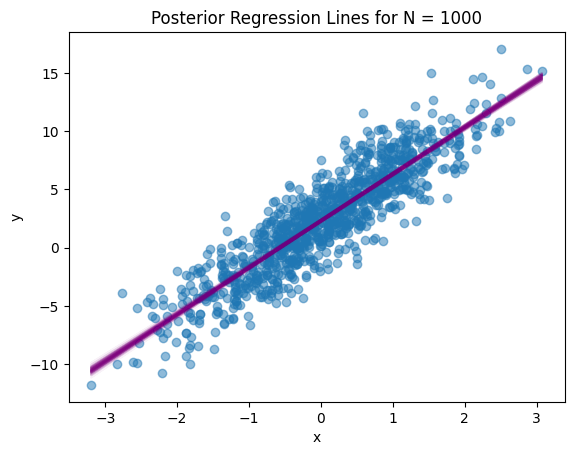

In [17]:
# graphically summarising results via scatter plot...
plt.scatter(x, y, alpha=0.5, label="Data")

# posterior regression lines...
posterior = fit2.draws_pd()

for i in range(100):
    a = posterior["alpha"].iloc[i]
    b = posterior["beta"].iloc[i]
    plt.plot(x, a + b * x, color="purple", alpha=0.05)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior Regression Lines for N = 1000")
plt.show()